# Week Session B

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("../../Datasets") / "FuelConsumptionCo2.csv"
data = pd.read_csv(data_path)

display(data.head())
print("Rows and columns:", data.shape)
print(data[["ENGINESIZE", "CO2EMISSIONS"]].isna().sum())

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


Rows and columns: (1067, 13)
ENGINESIZE      0
CO2EMISSIONS    0
dtype: int64


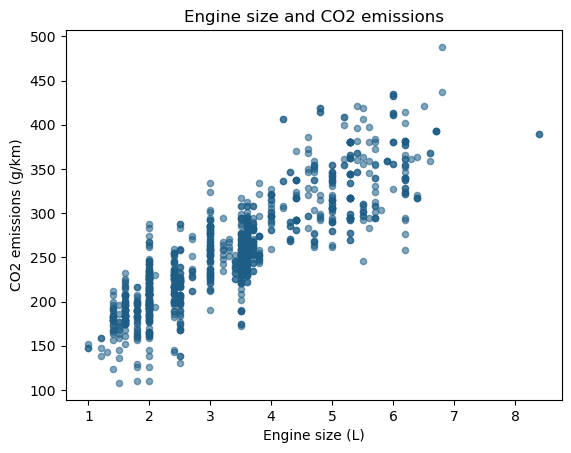

In [4]:
feature = "ENGINESIZE"
target = "CO2EMISSIONS"

data.plot.scatter(
    x=feature,
    y=target,
    alpha=0.55,
    color="#1d5d86"
)
plt.title("Engine size and CO2 emissions")
plt.xlabel("Engine size (L)")
plt.ylabel("CO2 emissions (g/km)")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X = data[[feature]]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 853
Test rows: 214


In [6]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient: {model.coef_[0]:.3f}")
print(f"Intercept: {model.intercept_:.3f}")

Coefficient: 38.993
Intercept: 126.290


In [7]:
predictions = model.predict(X_test)

comparison = pd.DataFrame({
    "engine_size": X_test[feature],
    "actual_co2": y_test,
    "predicted_co2": predictions
})

display(comparison.head())

,engine_size,actual_co2,predicted_co2
732,4.7,304,309.556702
657,3.5,221,262.765128
168,3.6,294,266.664426
86,3.0,221,243.268638
411,2.0,207,204.275660


In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

MAE: 24.097
MSE: 985.938
RMSE: 31.400
R2: 0.762
